In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import math as mt

# 1. Cash or CStat statistic

Let the expected number of signal counts be $n_s$, and given $n_{bkg}$, we have, using the fact that the distribution of the sum of two Poissonian RVs is a Possion with their means summed, the following likelihood for observing $n_{on}$ counts:
$$
L = \frac{(n_s+n_{bkg})^{n_{on}}e^{-(n_s+n_{bkg})}}{n_{on}!}
$$
Defining $l=-\ln L$, we have:
$$
l = n_{s} - n_{on}\ln (n_s+n_{bkg}) + \kappa
$$
where $\kappa$ denotes that the rest of the expression is a constant in terms of $n_{s}$. This has been done because while obtaining our MLE, we need to minimize $l$, and hence upon carrying out a partial differentiation wrt $n_{s}$, the term $\kappa$ would drop.
Thus, denoting our MLE for $n_{s}$ as $\hat{n}_s$, we have:

\begin{align}
&\left(\frac{\partial l}{\partial n_{s}}\right)_{n_s = \hat{n}_s} = 0 \nonumber\\
\implies& 1 - \frac{n_{on}}{\hat{n}_s+n_{bkg}} = 0 \nonumber\\
\implies& \hat{n}_s = n_{on}-n_{bkg}\\
\end{align}

Given $n_{on} = 10$, and $n_{bkg} = 3$, we have $\hat{n}_s = 7$, as our excess.

Taking the null hypothesis to be $n_s = 0$, we have the log-ratio statistic for our case as:
$$
\mu = 2 \left( l(n_s = 0) - l(n_s)\right)
$$
upon caarying out the subtraction in the above equation, $\kappa$ drops out, and we have:
\begin{align}
\mu &= 2\left(-n_{on}\ln (n_{bkg}) - \left(n_{s} - n_{on}\ln (n_s+n_{bkg})\right)\right) \nonumber\\
\mu & = -2\left(n_s+n_{on}\ln\left(\frac{n_{bkg}}{n_{s}+n_{bkg}}\right)\right)
\end{align}
For the observed data, $n_{on} = 10$, and given $n_{bkg} = 3$, using $\hat{n}_s = 7$, we have $\mu_0 = \mu(n_s = \hat{n}_s)$ as the value that our test statistic takes. Now, as per Wilks' theorem, $\mu_0$ is a random variable which follows the $\chi^2$ distribution with D.O.F. 1 upon repeated experiments, given that the null hypothesis (i.e., no signal) is true. For the given observation, we have the significance of detection given by:
$$
S = \Phi^{-1}(1-p)
$$
where
$$
p = \int_{\mu_0}^{\infty}f(\chi_1^2)d\chi^2
$$
This calculation is carried out in the code block below:

In [28]:
mu_0 = -2.0*(7.0+10.0*(np.log((3.0)/(10.0)))) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_one_sided) ## siginificance from p-value
print(f"Detection significance: {detection_sig:.2f} $\\sigma$")

Detection significance: 3.17 $\sigma$


Thus, the significance of detection is $S = 3.17\sigma$.

The $a\sigma$ confidence interval is given by $|\mu(n_s)-\mu(\hat{n}_s)|\le a^2$. The following code block finds the C.I. for $a=1,2$, and also plots the likelihood profile.

1 sigma confidence interval for \hat{n}_s: [4.16, 10.49]
2 sigma confidence interval for \hat{n}_s: [1.94, 14.71]


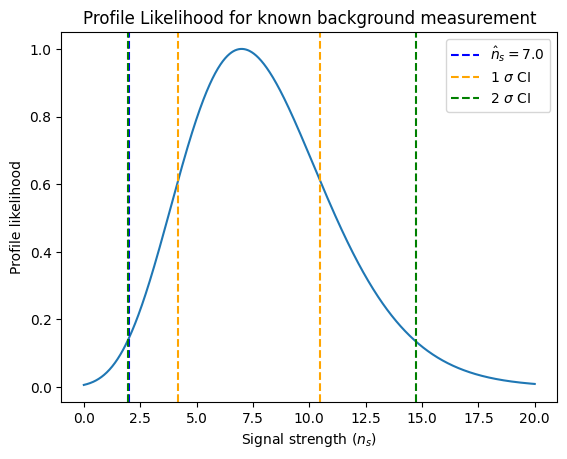

In [52]:
n_s_vals = np.linspace(0,20,1000)
n_bkg = 3.0
n_on = 10.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, 7.0, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 1 sigma CI
ci_1sigma = n_s_vals[mu_n_s <= 1.0]
print(f"1 sigma confidence interval for \\hat{{n}}_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")

## 2 sigma CI
ci_2sigma = n_s_vals[mu_n_s <= 4.0]
print(f"2 sigma confidence interval for \\hat{{n}}_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

## ploting 1 sigma and 2 sigma and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 7.0$')
plt.axvline(ci_1sigma[0], color='orange', linestyle='--', label='1 $\\sigma$ CI')
plt.axvline(ci_1sigma[-1], color='orange', linestyle='--')
plt.axvline(ci_2sigma[0], color='green', linestyle='--', label='2 $\\sigma$ CI')
plt.axvline(ci_2sigma[-1], color='green', linestyle='--')
plt.legend()
plt.show()

The $1\sigma$ C.I. for the excess is [4.16, 10.49]. The $2\sigma$ C.I. for the excess is [1.94, 14.71].

Now, for the case of $n_{on} = 5$, $n_{bkg}= 3$, the excess is $\hat{n}_s = 5 - 3 = 2$. The test statistic for this case becomes $\mu_0 = -2\left(2+5\ln\left(\frac{3}{5}\right)\right)$. It's significance is calculated in the code block below:

In [51]:
n_s_hat = 2.0
n_on = 5.0
n_bkg = 3.0
mu_0 = 2.0*(nll(n_on, 0.0, n_bkg) - nll(n_on, n_s_hat, n_bkg)) ## test-statistic varying as chi^2 with dof = 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_0, df=1) ## p-value for the observed test statistic
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for n_s = 2: {detection_sig:.2f} $\\sigma$")

Detection significance for n_s = 2: 1.05 $\sigma$


The significance of detection for this case is $1.05\sigma$. The code block plots the likelihood profile, and the $5\sigma$ upper limit on the excess.

5 sigma upper limit for \hat{n}_s: 22.67


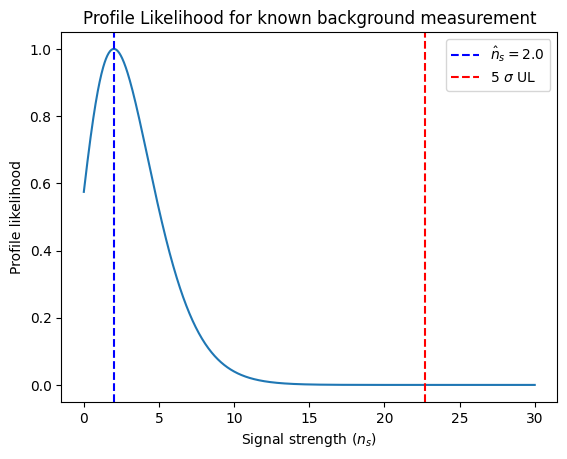

In [46]:
n_s_vals = np.linspace(0,30,1000)
n_bkg = 3.0
n_on = 5.0
n_s_hat = 2.0
def nll(n_on, n_s, n_bkg = 3.0):
    nll_val = n_s - n_on*np.log(n_s + n_bkg)
    return nll_val
mu_n_s = 2.0*(nll(n_on, n_s_vals, n_bkg) - nll(n_on, n_s_hat, n_bkg))
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for known background measurement")

## 5 sigma upper limit
ci_5sigma = n_s_vals[mu_n_s <= 25.0]
print(f"5 sigma upper limit for \\hat{{n}}_s: {ci_5sigma[-1]:.2f}")

## ploting 5 sigma UL and the best fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s = 2.0$')
plt.axvline(ci_5sigma[-1], color='red', linestyle='--', label='5 $\\sigma$ UL')
plt.legend()
plt.show()

The $5\sigma$ upper limit on the excess is 22.67.

# 2. WStat Statistic

Here, the expected background during measurements in $t_{on}$ is not known. Now, for a measurement of $t_{off}$, and $t_{on}$ durations, take $N_{off}$, and $N_{on}$ as the respective observed counts. Let $n_{b,~on}$ be the expected background when the detector is recording for a time $t_{on}$. As off-time measurements only contain the background, we have that $N_{off}$ varies as a Poisson random variable with mean say $n_{off}$. Now, assuming a constant bacgkround rate of $r_b = \frac{n_{off}}{t_{off}}$, during both the source off and source on measurements, we have $n_{b,~on} = t_{on}\frac{n_{off}}{t_{off}} = \alpha n_{off}$.

So, the likelihood of observing the data would be:
$$
L = \frac{n_{on}^{N_{on}}e^{-n_{on}}}{N_{on}!} \frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$
where $n_{on}$ is the expected source on-time measurement, and the factor corresponding to off-time measurement comes in due to it being an independent one form the on-time measurement. Since we model the counts in the on region being due to both the signal and the background, we would have the expected value of counts during $t_{on}$ to be $n_{on} = n_{s}+n_{b,on}$, where $n_{s}$ is the expected counts due to the source. This was possible because the sum of two Poissonian random variables being a Possion random variable with the mean the same as the sum of their individual means. So, we have:
$$
L = \frac{(n_{s}+\alpha n_{off})^{N_{on}}e^{-(n_{s}+\alpha n_{off})}}{N_{on}!}\frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$
Defining the negative log likelihood as in the first question:
$$
l = -\ln L = n_{s}+ \alpha n_{off} - N_{on}\ln(n_{s}+\alpha n_{off}) + n_{off} - N_{off}\ln n_{off} + C
$$
where $C$ is a constant independent of the parameters to be fixed by MLE, and thus, won't affect the minimization of $l$.

Now, the MLE for $n_{s}$ is:

\begin{align}
&\left(\frac{\partial l}{\partial n_s}\right)_{\hat{n}_{s}} = 0 \nonumber\\
\implies&~-\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+1 = 0
\end{align}
For $n_{off}$ we have:
\begin{align}
&\left(\frac{\partial l}{\partial n_{off}}\right)_{\hat{n}_{off}} = 0 \nonumber\\
\implies&~-\alpha\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+\alpha - \frac{N_{off}}{n_{off}} + 1 = 0 \nonumber \\
\implies&~\alpha\left[-\frac{N_{on}}{\hat{n}_{s}+\alpha n_{off}}+1\right] - \frac{N_{off}}{n_{off}} + 1 = 0 \nonumber
\end{align}
The first term on the LHS of the above equation is 0 from Eq. (1). So, we have, the MLE of $\hat{n}_{off}$ that minimizes $l$ at the gloabl maximum likelihood, as:
$$
\hat{n}_{off} = N_{off}
$$
So, we then have, with this value of $n_{off}$:
$$
\hat{n}_s + \alpha N_{off} = N_{on} \implies \hat{n}_{s} = N_{on} - \alpha N_{off}
$$
This is our MLE for $n_{s}$, and $n_{off}$.

Now, we have our test statistic for the background only hypothesis given by 
$$
\mu = 2 \left(l(n_s = 0,~\hat{n}_{off}|_{n_s = 0}) - l(n_s = N_{on} - \alpha N_{off}, n_{off} = \hat{n}_{off}|_{n_s})\right)
$$
and we have by Wilk's theorem that $\mu\sim\chi_{1}^2$.
The second term in the above equation is the global MLE of $n_s$ and $n_{off}$. The first term is obtained from the MLE of $n_{off}$ when $n_s$ is fixed at 0.
When $n_s = 0$, we have:
$$
\alpha\left[-\frac{N_{on}}{\alpha n_{off}}+1\right] - \frac{N_{off}}{n_{off}} + 1 = 0 \\
\implies \alpha + 1 = \frac{N_{on}+N_{off}}{n_{off}}\\
\implies n_{off} = \frac{N_{on}+N_{off}}{\alpha + 1}
$$
Now, $\mu$ can be calculated by defining the negative log-likelihood function with $n_s$ and $n_{off}$ as inputs. For a complicated enough scenario we would need to minimize the negative log-likelihood using minuit or other minimization packages. It is not needed to use Minuit here for obtaining signal significance, as the derivations of minima have been analytic. I carry out both to see consistency in the results. For the case of non-zero $n_s$, when obtaining profile likelihood, it is necessary to use Minuit, as the resulting MLE of $n_{off}$ at non-zero $n_s$ is the root of a complicated quadratic equation, which can be more efficiently handled using Minuit.

In [10]:
def nll_on_off(N_on, N_off, alpha, n_off, n_s = 0):
    """
    Inputs -->
    N_on [integer] : Observed counts with source on
    N_off [integer] : Observed counts with source off
    alpha [float] : Acceptance
    n_off [float] : Expected counts with source off
    n_s [float] : Expected counts with source on -- default value set to 0 for use in background only hypothesis
    Outputs -->
    nll_val [float] : Negative log likelihood value with the given observations modulo constants independent of expected values of n_s and and n_off
    """
    nll_val = 0
    nll_val += n_s + alpha * n_off - N_on * (mt.log(n_s + alpha * n_off))
    nll_val += n_off - N_off * mt.log(n_off)
    return nll_val

## Analytic way
### Calculation for background only hypothesis
N_on = 10.0
N_off = 6.0
alpha = 0.5
n_off_bkg_only = (N_on + N_off)/(alpha + 1.0)
nll_bkg_only = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = n_off_bkg_only, n_s = 0)
### Calculation for global minimum
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
mu_A = 2 * (nll_bkg_only - nll_global)
## mu_A should be a sample from chi^2 with D.O.F. of 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_A, df=1) ## p-value for mu_A
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for N_on = {N_on} in the analytic way: {detection_sig:.2f} $\\sigma$")

## Using Minuit -- just for consistency check, rest of analysis will be done with previous method
### Global minimum
from iminuit import Minuit
#### Building function that focues only on the parameters to maximize likelihood over
def nll_on_off_params_only(n_s, n_off):
    return nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = n_off, n_s = n_s)
#### Starting with initial guesses same as the analytic ones for quicker convergence
m_global = Minuit(
    nll_on_off_params_only,
    n_s   = n_s_global, ## recycling value defined earlier in code
    n_off = N_off,
)
#### Setting limits on n_s, given alpha can at most be 1
#### Setting limits on n_off given we already know we are finding the value for global minimum
m_global.limits["n_s"]   = (N_on - N_off, N_on + N_off)
m_global.limits["n_off"] = (N_off - 2, N_off + 2)
m_global.migrad()
### Background only
m_bkg = Minuit(
    nll_on_off_params_only,
    n_s   = 0,
    n_off = n_off_bkg_only, ## recycling from earlier definition in code
)
m_bkg.values["n_s"] = 0.0
m_bkg.fixed["n_s"]  = True
m_bkg.limits["n_off"] = (n_off_bkg_only - 1, n_off_bkg_only + 1) ## using known range for faster convergence
m_bkg.migrad()
### test statistic using minuit values
nll_bkg_only = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_bkg.values['n_off'], n_s = 0)
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_global.values['n_off'], n_s = m_global.values['n_s'])
mu_M = 2 * (nll_bkg_only - nll_global)
## mu_M should be a sample from chi^2 with D.O.F. of 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_A, df=1) ## p-value for mu_A
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for N_on = {N_on} using Minuit minimization: {detection_sig:.2f} $\\sigma$")

Detection significance for N_on = 10.0 in the analytic way: 2.38 $\sigma$
Detection significance for N_on = 10.0 using Minuit minimization: 2.38 $\sigma$


There is complete agreement between the detection significance using both methods. To procedd further, consider an aribtrary $n_{s}$. The likelihood maximizing value of $n_{off}$ at that $n_s$ then becomes:
$$
\alpha + 1 = \frac{\alpha N_{on}}{n_{s} + \alpha n_{off}} + \frac{N_{off}}{n_{off}}\\
\therefore (\alpha^2+\alpha) n_{off}^2 + \left((\alpha+1)n_s - \alpha(N_{on} + N_{off})\right)n_{off} - n_s N_{off} = 0
$$
finding the roots of this equation is complex. From here I will use Minuit to obtain the MLE of $n_{off}$ for different given $n_s$.

1 sigma confidence interval for \hat{n}_s: [3.87, 10.66]
2 sigma confidence interval for \hat{n}_s: [1.05, 14.98]


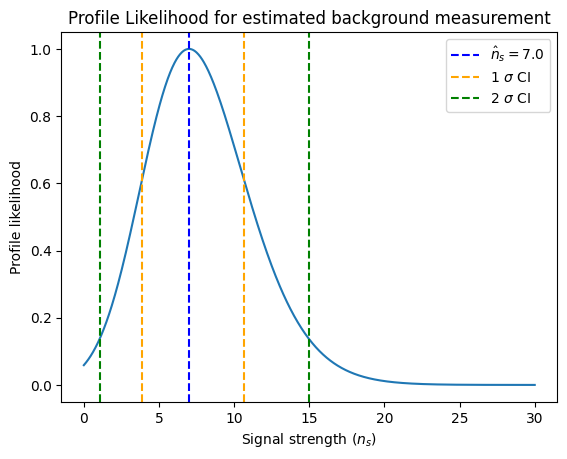

In [16]:
# Characterizing confidence intervals
N_on = 10.0
N_off = 6.0
alpha = 0.5
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
## profiling
n_s_vals = np.linspace(0.0, 30.0, 1000)
nll_at_ns = np.zeros(1000)
## defining root finding for finding likelihood maximizing value of n_off for an arbitrary n_off
for k in range(1000):
    m_ns = Minuit(
    nll_on_off_params_only,
    n_s   = 0,
    n_off = n_off_bkg_only, ## recycling from earlier definition in code
    )
    m_ns.values["n_s"] = n_s_vals[k]
    m_ns.fixed["n_s"]  = True
    m_ns.limits["n_off"] = (1e-6, None) ## using arbitrary range
    m_ns.migrad()
    nll_at_ns[k] = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_ns.values['n_off'], n_s = n_s_vals[k])

## test staitistic
mu_n_s = 2.0*(nll_at_ns - nll_global)
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for estimated background measurement")

## 1 sigma CI
ci_1sigma = n_s_vals[mu_n_s <= 1.0]
print(f"1 sigma confidence interval for \\hat{{n}}_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")

## 2 sigma CI
ci_2sigma = n_s_vals[mu_n_s <= 4.0]
print(f"2 sigma confidence interval for \\hat{{n}}_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

## ploting 1 sigma and 2 sigma and the best fit
plt.axvline(n_s_global, color='blue', linestyle='--', label=f'$\\hat n_s = {n_s_global}$')
plt.axvline(ci_1sigma[0], color='orange', linestyle='--', label='1 $\\sigma$ CI')
plt.axvline(ci_1sigma[-1], color='orange', linestyle='--')
plt.axvline(ci_2sigma[0], color='green', linestyle='--', label='2 $\\sigma$ CI')
plt.axvline(ci_2sigma[-1], color='green', linestyle='--')
plt.legend()
plt.show()


The profile likelihood follows a $\chi_1^2$ distribution as expected, and the confidence intervals are marked in the graphs above.

For the case of $N_{on} = 5$ and $N_{off} = 6$, the global MLE of $n_s$ is $\hat{n}_s = N_{on}-\alpha N_{off} = 5 - 0.5\times 6 = 2$, and $\hat{n}_{off} = 6$. The following code cells demonstrate the necessary calculations.

In [18]:
## Making use of the nll_on_off function already defined in previous cell
### Calculation for background only hypothesis
N_on = 5.0
N_off = 6.0
alpha = 0.5
n_off_bkg_only = (N_on + N_off)/(alpha + 1.0)
nll_bkg_only = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = n_off_bkg_only, n_s = 0)
### Calculation for global minimum
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
mu_A = 2 * (nll_bkg_only - nll_global)
## mu_A should be a sample from chi^2 with D.O.F. of 1
p_value = 1.0 - sp.stats.chi2.cdf(mu_A, df=1) ## p-value for mu_A
p_val_one_sided = p_value / 2.0 ## converting to one-sided p-value
detection_sig = sp.stats.norm.isf(p_val_one_sided) ## siginificance from p-value
print(f"Detection significance for N_on = {N_on} : {detection_sig:.2f} $\\sigma$")

Detection significance for N_on = 5.0 : 0.83 $\sigma$


There is a $0.83\sigma$ significance for this signal, as $n_s < n_{b,~on} = \alpha n_{off} = 3$. So, we cannot put a $n\sigma$ lower bound on this, for some integer $n$. So, the code cell below shows the calculation of the $5\sigma$ upper limit.

5 sigma upper limit for \hat{n}_s: 23.15


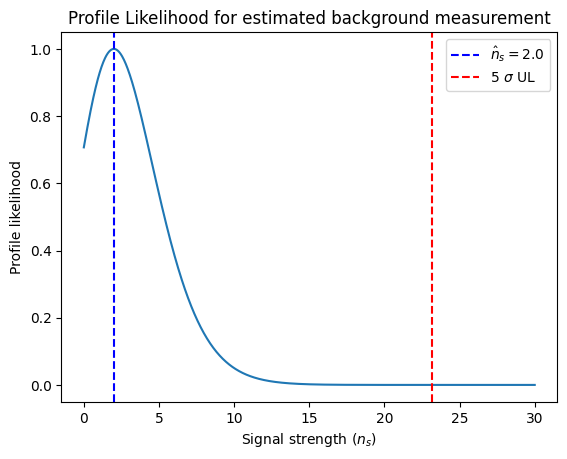

In [20]:
# Characterizing 5-sigma upper limit intervals
N_on = 5.0
N_off = 6.0
alpha = 0.5
n_s_global = N_on - alpha * N_off
nll_global = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = N_off, n_s = n_s_global)
## profiling
n_s_vals = np.linspace(0.0, 30.0, 1000)
nll_at_ns = np.zeros(1000)
## defining root finding for finding likelihood maximizing value of n_off for an arbitrary n_off
for k in range(1000):
    m_ns = Minuit(
    nll_on_off_params_only,
    n_s   = 0,
    n_off = n_off_bkg_only, ## recycling from earlier definition in code
    )
    m_ns.values["n_s"] = n_s_vals[k]
    m_ns.fixed["n_s"]  = True
    m_ns.limits["n_off"] = (1e-6, None) ## using arbitrary range
    m_ns.migrad()
    nll_at_ns[k] = nll_on_off(N_on = N_on, N_off = N_off, alpha = alpha, n_off = m_ns.values['n_off'], n_s = n_s_vals[k])

## test staitistic
mu_n_s = 2.0*(nll_at_ns - nll_global)
profile_lkl = np.exp(-0.5*mu_n_s) ## since nll = - ln(lkl)
plt.plot(n_s_vals, profile_lkl)
plt.xlabel("Signal strength ($n_s$)")
plt.ylabel("Profile likelihood")
plt.title("Profile Likelihood for estimated background measurement")

## 5 sigma upper limit
ci_5sigma = n_s_vals[mu_n_s <= 25.0]
print(f"5 sigma upper limit for \\hat{{n}}_s: {ci_5sigma[-1]:.2f}")

## ploting 5 sigma UL and the best fit
plt.axvline(n_s_global, color='blue', linestyle='--', label=r'$\hat{n}_s = 2.0$')
plt.axvline(ci_5sigma[-1], color='red', linestyle='--', label='5 $\\sigma$ UL')
plt.legend()
plt.show()

The $5\sigma$ upper limit on the excess is 23.15. This has been shown in the above plot.

The difference in the two cases, where $n_{s} > n_{b,~on}$ and $n_{s} < n_{b,~on}$ as in the first and second part of the question, is that when the excess is less than the expected background counts, our confidence to call it a signal decreases. The best we can do is to characterize an upper limit on where the true excess count can lie upto some confidence. Whereas, when the observed excess is more than the expected background, we know with greater confidence that it is a signal and can construct a much stricter confidence intervals, which would be more easily testable using observations of other experiments.

The likelihood of CStat statistic involved only one unkown parameter, which was our parameter of interest, the excess. That had to be estimated using data. However, for WStat statistic, there are two unkown parameters, the expected excess with source on and the expected count rate with source off. Thus, the likelihood in the second case gained an extra probability factor corresponding to $n_{off}$ and thus, we had to profile over different values of $n_s$ and obtain our confidence intervals using the procedure motivated by Wilk's theorem.

# 3. 1-D Signal Analysis of Gaussian Pulses with Boxcar Kernel 

In [34]:
# Construction of 1D time series
dt = 1e-3   # resolution
t_min, t_max = 0.0, 25.0    # observation span in time
t_arr = np.linspace(t_min, t_max, int((t_max-t_min)/dt)) # time array

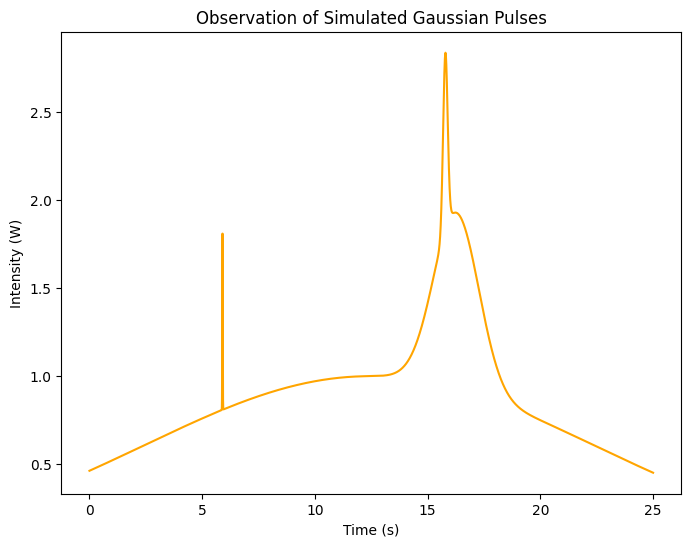

In [38]:
# Generating Gaussian pulses
pulse_centers = np.random.choice(t_arr, 4) # Four randomly positioned Gaussian pulses in the entire duration of observation
pulse_widths = np.array([1e-2, 1e-1, 1.0, 1e1]) # Different widths for each pulse
pulse_amp = 1.0 # Same amplitude of all pulses
observation = np.zeros(len(t_arr))

for pulse_i in range(len(pulse_centers)):
    gauss_phase = -0.5*(((t_arr - pulse_centers[pulse_i])**2)/((pulse_widths[pulse_i])**2)) # Phase of the Gaussian pulse
    pulse_func = pulse_amp * np.exp(gauss_phase)    # Pulse as would be observed in time
    observation += pulse_func

# Plotting the observation
fig, ax = plt.subplots(figsize = (8,6))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Intensity (W)")
ax.set_title("Observation of Simulated Gaussian Pulses")
ax.plot(t_arr, observation, color = "orange")
plt.show()

Top-hat kernel of radius $R$ is defined as:
$$
K(t) = \frac{1}{2R}
$$
for $|t| \le R$, otherwise 0. This function needs to be convlved with the signal for different values of the radius $R$.

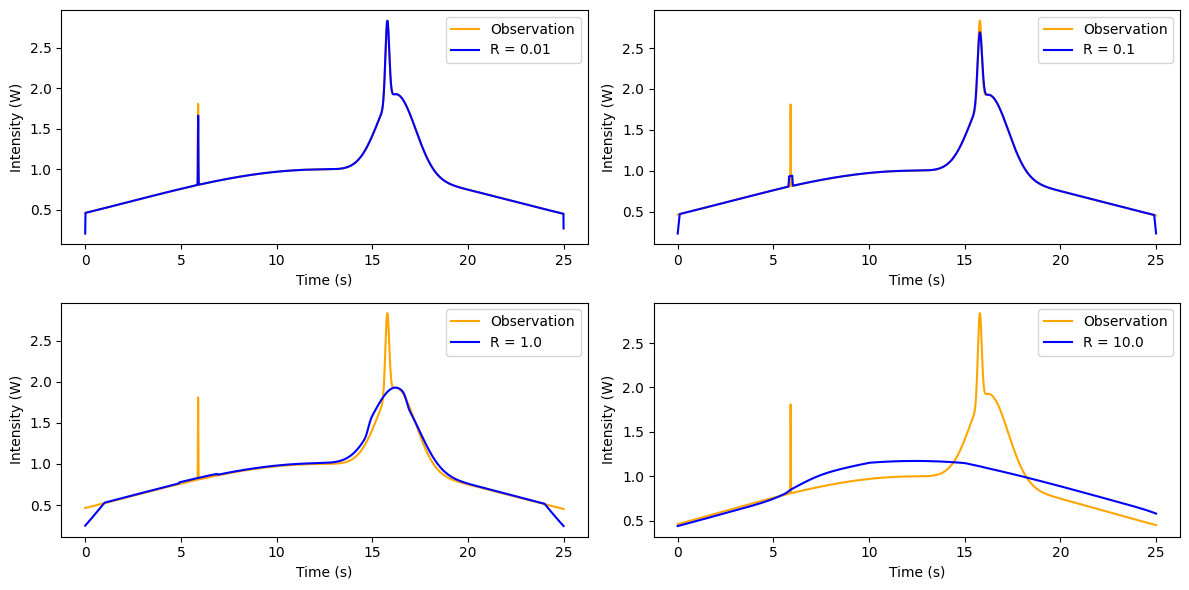

In [56]:
# Defining top-hat kernel
def tophat_ker(times, radius):
    """
    Inputs -->
    times [array, float] : the aray of lags
    radius [float] : the radius of the top-hat kernel
    Output -->
    ker [array, float] : the normalized top-hat kernel centered at 0 of the lag space.
    """
    nonzero_mask = np.abs(times) < radius   # kernel centered at 0 of the times array
    ker = np.zeros(len(times))
    ker[nonzero_mask] = (0.5)/(radius)
    return ker

radius_vals = np.array([1e1, 1e2, 1e3, 1e4]) * dt # kernel radius in temrs of the timing resolution
convolved_obs = {}  # empty dictionary to store different convolved obsevation arrays
lag_space = np.arange(-12.5, 12.5, dt)  # maximum possible lag
for r in radius_vals:
    ker = tophat_ker(times = lag_space, radius = r)
    convolved_obs[r] = np.convolve(observation, ker, mode = "same")   # Convolution step

# Visualization of the original observation vs after convolution with top-hat kernel
## plotting on same axes for comparability with and without convolution

fig, ax = plt.subplots(2,2, figsize = (12,6))
ik = [(0,0), (0,1), (1,0), (1,1)]
for r_i in range(len(radius_vals)):
    radius = radius_vals[r_i]
    i, k = ik[r_i]
    ## Original observation
    ax[i,k].plot(t_arr, observation, color = "orange", label = 'Observation')
    ax[i,k].set_xlabel("Time (s)")
    ax[i,k].set_ylabel("Intenisty (W)")
    ax[i,k].legend()
    ## Normalizing convolution, which otherwise takes very large values for small R for comparability with signal
    normed_conv = convolved_obs[radius]/np.trapezoid(convolved_obs[radius])
    normed_conv = np.trapezoid(observation) * normed_conv
    ax[i,k].plot(t_arr, normed_conv, color = "blue", label = f"R = {radius}")
    ax[i,k].legend()
    ax[i,k].set_xlabel("Time (s)")
    ax[i,k].set_ylabel("Intensity (W)")
plt.tight_layout()
plt.show()

When the kernel radius is $0.01$ it can be seen that the observation and the convolution both are overlappin each other excpet for the case of 1 peak, where the kernel radius is matching the Gaussian width. For that peak, the convolved signal has a lower height. It can be seen that there is near perfect overlap in all other less wide Gaussian peaks.

As the kernel radius is increased further to $0.1$, such that it goes to the case where it is 10 times as much larger than the signal with width $0.01$, it can be seen that the peak corresponding to this small signal has now become more suprressed after the convolution. Then, a small mismatch can be seen between original and convolved peaks corresponding to Gaussian of width $0.1$.

As the kernel radius further increases to $1$ it is again seen that the peaks corresponding to Gaussians of lower widths get suppressed, teh one with similar width as the radius stays roughly at the corresponding amplitude, and the wider signal stays as it after convolution.

As the radius is now $10$ it can be seen that the overlap with all other Gaussians that have lower spreads are suppressed as a result of convolution and naturally, only the widest signal survives.

Thus, aplying kernel is a way of choosing, or filtering signals of different characteristic widths in time so that we could find out the signals of interest. For example, if we were interested in observing the signal with width in time as $10$, it is useful to use a tophat kernel with radius $10$.

If we are interested in measuring shorter pulses then we must start by using tophat kernels with larger raadius so that we first get the signals that contribute to the observation with larger spreads, an then effectively subract out those parts and then reduce the top-hat kernel's radius and repeat for as much as is required until obtaining signal of interest. So in reality where we do not know teh widths of the signals involved, we need to loop through kernles of varying radii so that we could find out what components of different widths contribute to the observed signal.

The code cell below moves on to the analysis of kernel and signal using Fast Fourier Transform.

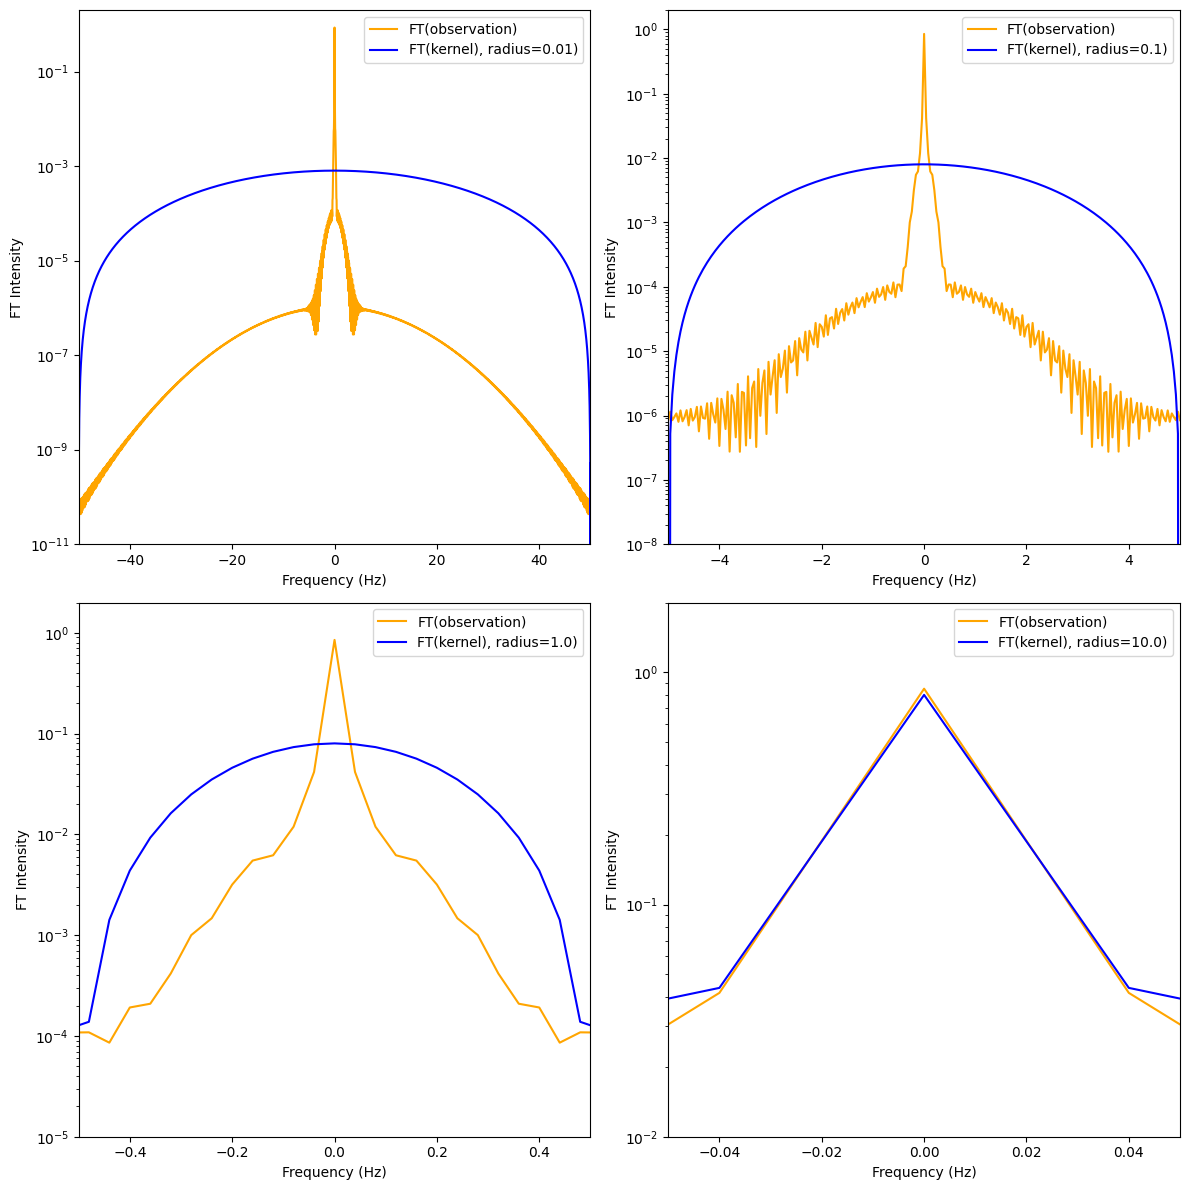

In [79]:
# Plotting observation FFT and kernel FFT on the same axes for comparison
freq_shifted = np.fft.fftshift(np.fft.fftfreq(len(t_arr), dt))  # frequency axis
ft_signal = np.fft.fftshift(np.fft.fft(observation))    # FFT of observed signal
ft_signal_norm = np.abs(ft_signal)**2/np.trapezoid(np.abs(ft_signal)**2)  # Taking ||^2 to plot intensity of FT on real axes

fig, ax = plt.subplots(2,2, figsize = (12,12))
for r_i in range(len(radius_vals)):
    radius = radius_vals[r_i]
    i, k = ik[r_i]  # Recycling the same plot index array as in previous cell
    ker = tophat_ker(times = lag_space, radius = radius)
    ft_ker = np.fft.fftshift(np.fft.fft(ker))
    ft_ker_norm = np.abs(ft_ker)**2/np.trapezoid(np.abs(ft_ker)**2) # Normalizing for visual comparsion
    freq_cut = 0.5/radius   # applying cut to focus for paterns in central lobe
    # Semilog plot to see better patterns in the Fourir space
    ax[i,k].semilogy(freq_shifted, ft_signal_norm, color = 'orange', label = "FT(observation)")   # plot the FFT of signal
    ax[i,k].semilogy(freq_shifted, ft_ker_norm, color = 'blue', label = f"FT(kernel), radius={radius})")
    ax[i,k].legend()
    ax[i,k].set_xlabel("Frequency (Hz)")
    ax[i,k].set_ylabel("FT Intensity")
    # Dynamic clipping of frequency axis to focus on the cenral lobe of the top-hat kernel, after which it is just a dying sinc function.
    ax[i,k].set_xlim(-freq_cut, freq_cut)
    # Dyanmic lower limit of y-axis to acheve proper maginification to see trends in Foruier space
    ax[i,k].set_ylim(1e-11*(10.0)**(3*r_i), 2.0)
plt.tight_layout()
plt.show()

The plots above show the central lobe of the tophat kernel for the different values of the chosen radii. It can be seen that when $R = 0.01$, the kernel's fourier tranform (KFT) is constant over a wide frequency range that encompasses all the frequencies present in the signal fourier transformt (SFT). So, when KFT and SFT are multiplied, we essentially get back the SFT without any change. This naturally connects to how the convolution of the signal with this kernel essentially gave back the signal, with only slight modifications at the peak where Gaussian width matched the kernel radius. This falloff can also be seen in the Fourier space where towards the edges of the KFT central lobe, the SFT has started falling off.

Simlarly for the case of krnel with radius $R = 0.1$, it can be seen that the central lobe of the KFT now coincides with the region of the SFT where the frequencies are lesser than the frequency span of the kernel. Thus, the KFT upon multiplying to the SFT in this case, causes the filtering out of that part of the signal which corresponds to larger frequency than the kernel's. Thus, the kernel is effectively acting as a low pass filter.

Now, again, for the case of the tophat kernel with radius $R = 1$, we see that central lobe now causes the higher frequencies to be filtered away and only those component of the signal with freuqncy less than the span of the central lobe are going to survive upon multiplication.

The same holds for the case where $R = 10$, whereby now all components of the signal excpet for the lowest frequency spread pulse have died out, and the KFT and the SFT are essentially overlapping, so that upon multiplication only the lowest frequency survives and the higher parts die out.

Thus, in conclusion we can say that the top-hat kernel acts as a low pass filter for signal with a $f_{cut} = \frac{1}{2R}$. The Gaussian pulse survives if $f_{pulse} < f_{cut}$, which means $R < \pi\sigma$, where $\sigma$ is the pulse width, otherwises it is suppressed.